**Insurance Risk Modeling: Claim Frequency & Severity Analysis**

Objective

The objective is to analyze insurance policy/claim data and answer two important questions:

Claim Frequency: How often does a policyholder make a claim?

Claim Severity: How large is the claim when a claim occurs?

We will identify the factors that influence insurance risk and build statistical models to predict:Claim Frequency and Claim Severity.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
#LOAD DATASET
df = pd.read_csv("insurance_claims_dataset.csv")
print(df.shape)
print(df.head())

(2003, 10)
   policy_id   age  gender  vehicle_age  annual_mileage vehicle_type  \
0  POL100001  21.0    Male          7.5         22354.0          SUV   
1  POL100002  55.0    Male          5.3          9235.0          SUV   
2  POL100003  50.0    Male          8.5         13217.0          SUV   
3  POL100004  23.0  Female          3.8         14869.0    Hatchback   
4  POL100005  66.0    Male          9.2         13675.0        Sedan   

   policy_tenure  claim_count  claim_amount   premium  
0            4.8            0          0.00  13010.94  
1            2.1            0          0.00  13087.46  
2            1.6            0          0.00  11258.91  
3            1.9            0          0.00   9696.16  
4            3.9            1      16645.64  13814.34  


policy_id: A unique identifier for each insurance policy.

age: The age of the policyholder (numerical).

gender: The gender of the policyholder (categorical, e.g., Male/Female).

vehicle_age: The age of the vehicle in years (numerical).

annual_mileage: The approximate distance driven by the vehicle annually in kilometers (numerical).

vehicle_type: The type of vehicle (categorical, e.g., SUV, Hatchback, Sedan).

policy_tenure: The duration in years the policy has been active (numerical).

claim_count: The number of claims made by the policyholder (count/integer).

claim_amount: The total financial amount of claims made by the policyholder (numerical).

premium: The insurance premium paid by the policyholder (numerical).

 **DATA CLEANING & EDA PORTION**

policy_id         0.0
age               0.0
gender            0.0
vehicle_age       0.0
annual_mileage    0.0
vehicle_type      0.0
policy_tenure     0.0
claim_count       0.0
claim_amount      0.0
premium           0.0
dtype: float64
Duplicates: 0
Empty DataFrame
Columns: [policy_id, age, gender, vehicle_age, annual_mileage, vehicle_type, policy_tenure, claim_count, claim_amount, premium]
Index: []
Empty DataFrame
Columns: [policy_id, age, gender, vehicle_age, annual_mileage, vehicle_type, policy_tenure, claim_count, claim_amount, premium]
Index: []
Empty DataFrame
Columns: [policy_id, age, gender, vehicle_age, annual_mileage, vehicle_type, policy_tenure, claim_count, claim_amount, premium]
Index: []
Empty DataFrame
Columns: [policy_id, age, gender, vehicle_age, annual_mileage, vehicle_type, policy_tenure, claim_count, claim_amount, premium]
Index: []


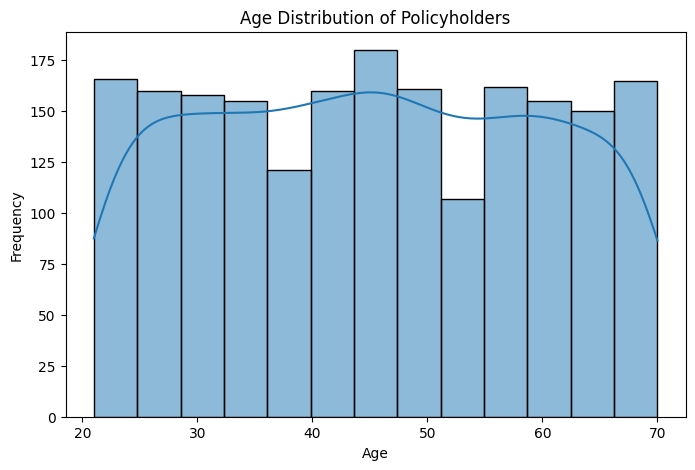

In [16]:
#CHECK MISSING VALUES
df.isnull().sum()
missing = df.isnull().sum() / len(df) * 100
print(missing.sort_values(ascending=False))#Percentage of missing values

#FOR NUMERICL VALUES MISSING VALUE HNDLE
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

#FOR CATEGORICAL VALUES MISSING VALUE HNDLE
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#REMOVE DUPLICATE VALUES
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

#REMOVE INVALID COLUMN
print(df[df["age"] <= 0])
print(df[df["vehicle_age"] < 0])
print(df[df["claim_count"] < 0])
print(df[df["claim_amount"] < 0])

#EDA
plt.figure(figsize=(8,5))

sns.histplot(df["age"], kde=True)

plt.title("Age Distribution of Policyholders")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


The age distribution of policyholders appears to be relatively uniform across the age groups displayed.

**Claim Count Distribution**

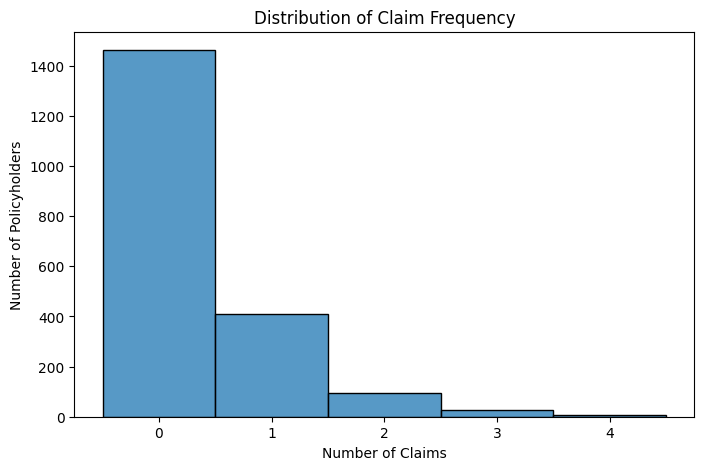

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["claim_count"], discrete=True)
plt.title("Distribution of Claim Frequency")
plt.xlabel("Number of Claims")
plt.ylabel("Number of Policyholders")
plt.show()

Insurance claim frequency is usually:

0 claims → many customers

1 claim → fewer customers

2 claims → even fewer

3+ claims → relatively rare

This makes count distributions such as Poisson or Negative Binomial useful.

**Zero Claim Percentage**

In [19]:
zero_claims = (df["claim_count"] == 0).mean()
print("Percentage with zero claims:", zero_claims * 100,"%")

Percentage with zero claims: 73.15 %


**Claim Amount Distribution**

(535, 10)


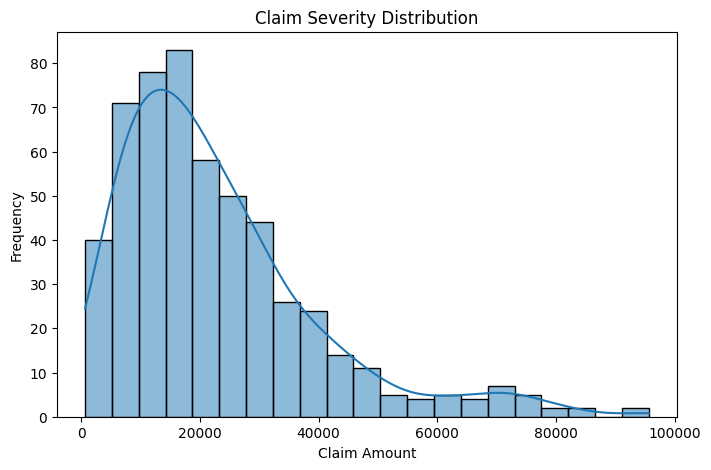

In [21]:
severity = df[df["claim_amount"] > 0].copy()
print(severity.shape)
plt.figure(figsize=(8,5))
sns.histplot(severity["claim_amount"], kde=True)
plt.title("Claim Severity Distribution")
plt.xlabel("Claim Amount")
plt.ylabel("Frequency")

plt.show()

Insurance claim severity is usually right-skewed.

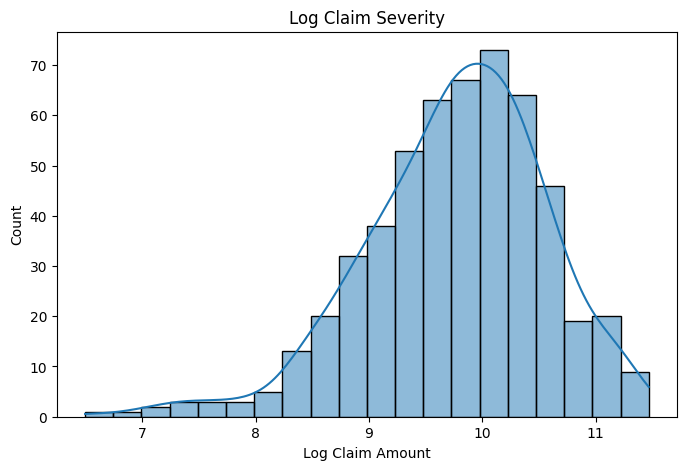

In [23]:
severity["log_claim_amount"] = np.log1p(
    severity["claim_amount"]
)
plt.figure(figsize=(8,5))
sns.histplot(
    severity["log_claim_amount"],
    kde=True
)
plt.title("Log Claim Severity")
plt.xlabel("Log Claim Amount")
plt.show()

**Correlation Analysis**

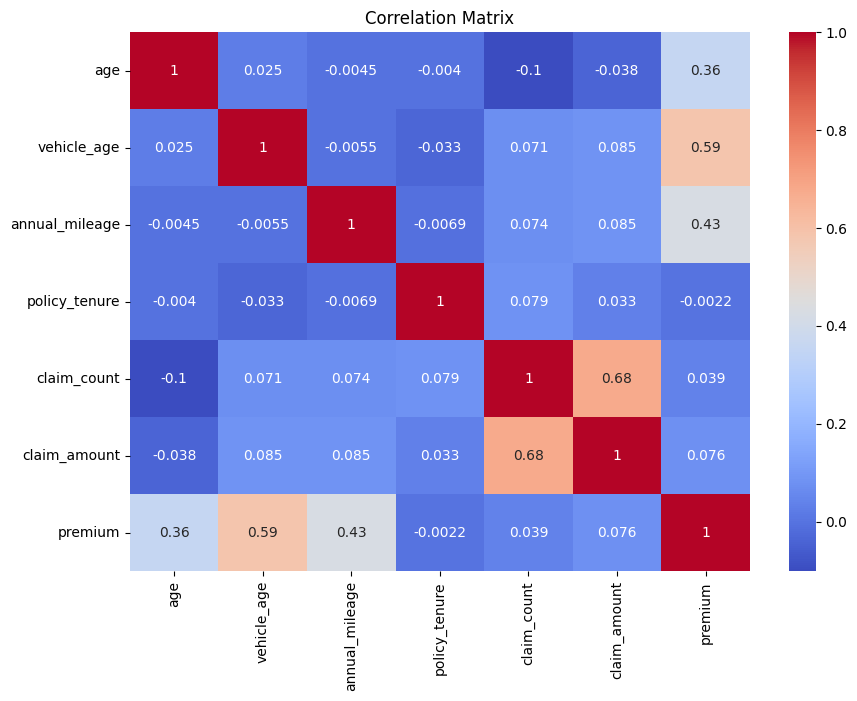

In [24]:
numeric = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,7))
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

Claim Count and Claim Amount: There's a strong positive correlation between claim_count and claim_amount (0.68), which suggests that more claims generally lead to higher total claim amounts.
Premium and Vehicle Age: Premium shows a moderate positive correlation with vehicle_age (0.59), indicating that older vehicles might be associated with higher premiums. There's also a moderate correlation between premium and age (0.36), and annual_mileage (0.43) with vehicle_age.
Most other numerical features have relatively weak correlations with each other.

**Claims by Age**

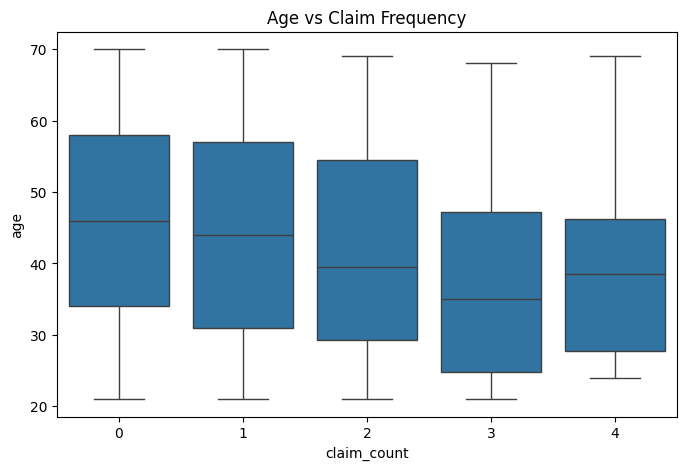

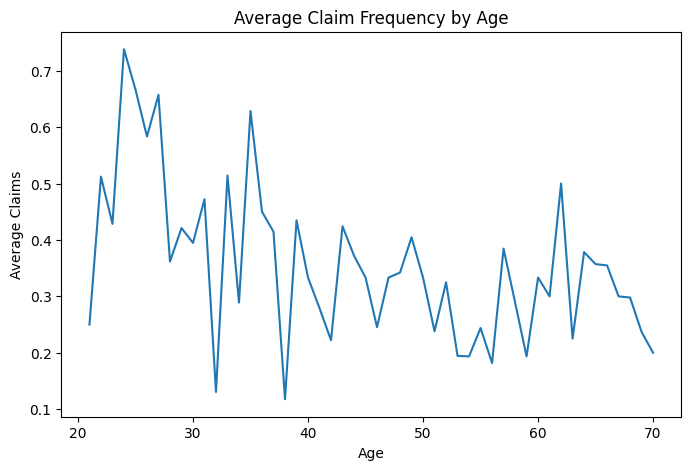

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="claim_count",
    y="age"
)
plt.title("Age vs Claim Frequency")
plt.show()
age_claims = df.groupby("age")["claim_count"].mean()
age_claims.plot(figsize=(8,5))
plt.title("Average Claim Frequency by Age")
plt.xlabel("Age")
plt.ylabel("Average Claims")
plt.show()

The plots indicate a higher average claim frequency among younger policyholders, particularly in their 20s, with a generally decreasing trend as age increases. The box plot also suggests that policyholders with 0 claims exhibit a wider age distribution compared to those with one or more claims.

**Vehicle Age vs Claims**

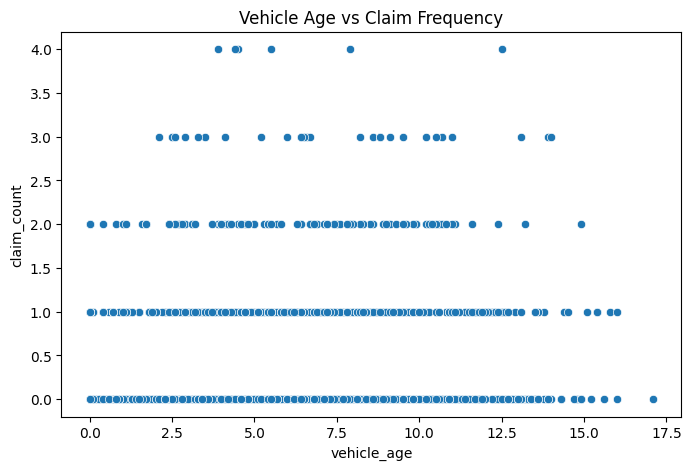

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="claim_count"
)
plt.title("Vehicle Age vs Claim Frequency")
plt.show()

The scatter plot for 'Vehicle Age vs Claim Frequency' does not show a clear linear relationship. Claims (0, 1, 2, 3, 4) appear to be somewhat uniformly distributed across different vehicle ages, with no obvious concentration of higher claim counts at specific vehicle ages.

**Annual Mileage vs Claims**

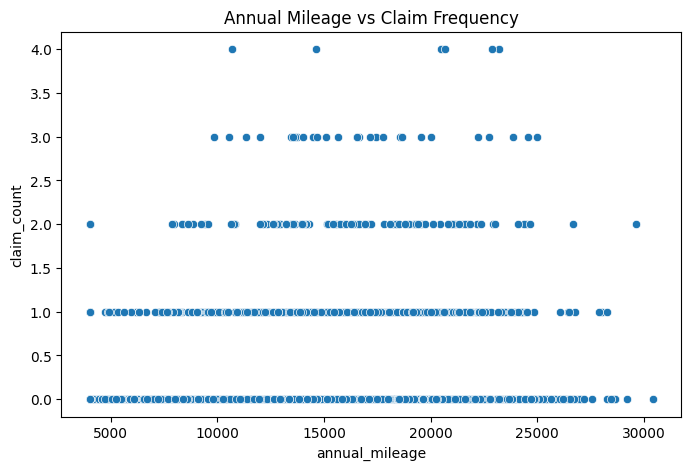

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="annual_mileage",
    y="claim_count"
)
plt.title("Annual Mileage vs Claim Frequency")
plt.show()

Higher annual mileage may expose vehicles to more driving risk and therefore may be associated with higher claim frequency.

**Claim Frequency Modeling**

Now we build the first statistical model.
Our response variable is:
$$ Y = \text{number of claims} $$
Since claim count is a non-negative integer:
$$ Y=0,1,2,3,\ldots $$
a Poisson regression is a natural starting model.

In [31]:
train, test = train_test_split(
    df,
    test_size=0.20,
    random_state=123
)
print(train.shape)
print(test.shape)


(1600, 10)
(400, 10)


Suppose we use:
age,vehicle age,
annual mileage,policy tenure as predictors.

In [32]:
#POISSON REGRESSION
poisson_model = smf.glm(
    formula="""
    claim_count ~ age +
                  vehicle_age +
                  annual_mileage +
                  policy_tenure
    """,
    data=train,
    family=sm.families.Poisson()
).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                 1600
Model:                            GLM   Df Residuals:                     1595
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1229.6
Date:                Fri, 02 Oct 2026   Deviance:                       1533.5
Time:                        16:12:07   Pearson chi2:                 1.92e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.03738
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.5395      0.235     -6.

INTERPRETATION OF AGE
Coefficient:
$$ \beta=-0.0140 $$
Because it is negative:
As age increases, predicted claim frequency decreases, holding the other variables constant.
For one additional year:
$$ e^{-0.0140}=0.9861 $$
So the expected claim rate is multiplied by about 0.986, approximately a 1.39% decrease per additional year, holding other variables constant.

**Check Poisson Assumption:**

A major assumption of Poisson regression is approximately
E(Y)≈Var(Y)

In [35]:
mean_claims = df["claim_count"].mean()
variance_claims = df["claim_count"].var()
print("Mean:", mean_claims)
print("Variance:", variance_claims)

Mean: 0.3525
Variance: 0.4424649824912465


Variance>Mean

This is called overdispersion.
In that situation, Negative Binomial regression may be more appropriate.

**Negative Binomial Regression**

In [37]:
nb_model = smf.glm(
    formula="""
    claim_count ~ age +
                  vehicle_age +
                  annual_mileage +
                  policy_tenure
    """,
    data=train,
    family=sm.families.NegativeBinomial()
).fit()
print(nb_model.summary())

#DIFF USING AIC
print("Poisson AIC:", poisson_model.aic)
print("Negative Binomial AIC:", nb_model.aic)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                 1600
Model:                            GLM   Df Residuals:                     1595
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1216.8
Date:                Fri, 02 Oct 2026   Deviance:                       1125.0
Time:                        16:21:42   Pearson chi2:                 1.42e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.02719
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.5537      0.273     -5.

/tmp/ipykernel_777/3468878325.py:9: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  family=sm.families.NegativeBinomial()


AIC OF NEGATIVE BINOMIAL IS LOWER SO IT IS BETTER FIT THAN POISSION

**FREQUENCY PREDICTION**

In [38]:
test["predicted_frequency"] = nb_model.predict(test)

print(
    test[
        ["claim_count", "predicted_frequency"]
    ].head(10)
)

      claim_count  predicted_frequency
1342            0             0.269830
1338            0             0.298036
189             0             0.434870
1332            1             0.531498
1816            0             0.221601
1685            0             0.443463
657             0             0.215484
1846            0             0.202652
554             0             0.360583
1963            0             0.216687


**MSE & MAE**

In [40]:
rmse_frequency = np.sqrt(
    mean_squared_error(
        test["claim_count"],
        test["predicted_frequency"]
    )
)
mae_frequency = mean_absolute_error(
    test["claim_count"],
    test["predicted_frequency"]
)

print("Frequency RMSE:", rmse_frequency)
print("Frequency MAE:", mae_frequency)

Frequency RMSE: 0.6428934210276026
Frequency MAE: 0.4938365872487441


**Actual vs Predicted Frequency**

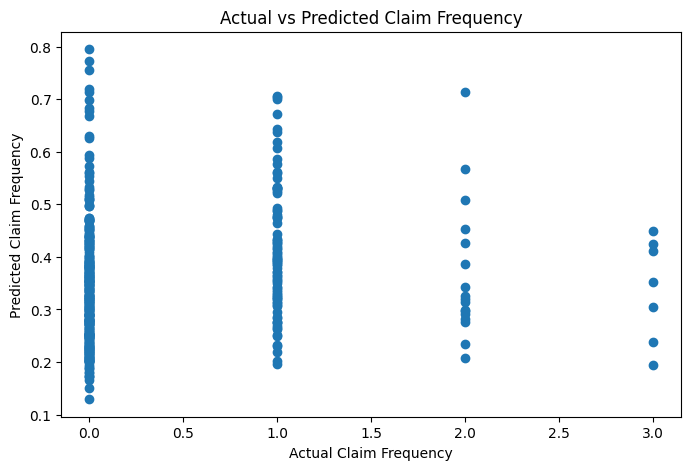

In [41]:
plt.figure(figsize=(8,5))
plt.scatter(
    test["claim_count"],
    test["predicted_frequency"]
)

plt.xlabel("Actual Claim Frequency")
plt.ylabel("Predicted Claim Frequency")
plt.title("Actual vs Predicted Claim Frequency")

plt.show()

**Claim Severity Modeling**

Now we model:
$$ Y = \text{claim amount} $$
but only for customers who have a positive claim amount.

In [43]:
severity = df[df["claim_amount"] > 0].copy()
severity_train, severity_test = train_test_split(
    severity,
    test_size=0.20,
    random_state=123
)

**Gamma Regression:**

Claim amounts are positive and often right-skewed.
Therefore Gamma regression with a log link is commonly useful.

In [44]:
gamma_model = smf.glm(
    formula="""
    claim_amount ~ age +
                   vehicle_age +
                   annual_mileage +
                   policy_tenure
    """,
    data=severity_train,
    family=sm.families.Gamma(
        link=sm.families.links.Log()
    )
).fit()
print(gamma_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           claim_amount   No. Observations:                  428
Model:                            GLM   Df Residuals:                      423
Model Family:                   Gamma   Df Model:                            4
Link Function:                    Log   Scale:                         0.51029
Method:                          IRLS   Log-Likelihood:                -4674.2
Date:                Fri, 02 Oct 2026   Deviance:                       218.87
Time:                        16:58:07   Pearson chi2:                     216.
No. Iterations:                    10   Pseudo R-squ. (CS):            0.04579
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          9.5533      0.183     52.

This output is from your severity model, where the dependent variable is claim_amount.

The model is estimating:

log(E(claim amount))=9.5533+0.0026(age)+0.0111(vehicle_age)+0.0000266(annual_mileage)−0.0336(policy_tenure)

**Predict Claim Severity**

In [46]:
severity_test["predicted_severity"] = (
    gamma_model.predict(severity_test)
)
rmse_severity = np.sqrt(
    mean_squared_error(
        severity_test["claim_amount"],
        severity_test["predicted_severity"]
    )
)
mae_severity = mean_absolute_error(
    severity_test["claim_amount"],
    severity_test["predicted_severity"]
)
print("Severity RMSE:", rmse_severity)
print("Severity MAE:", mae_severity)

Severity RMSE: 15819.727169687787
Severity MAE: 12199.627033908046


**Actual vs Predicted Severity**

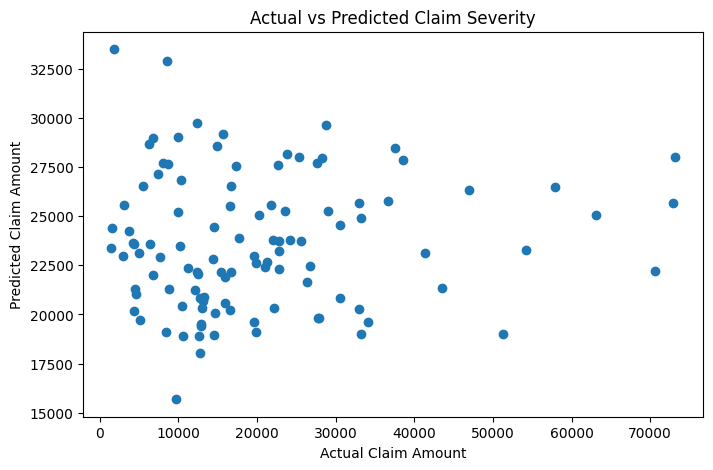

In [47]:
plt.figure(figsize=(8,5))

plt.scatter(
    severity_test["claim_amount"],
    severity_test["predicted_severity"]
)
plt.xlabel("Actual Claim Amount")
plt.ylabel("Predicted Claim Amount")
plt.title("Actual vs Predicted Claim Severity")

plt.show()

We have:

$$ E(\text{Loss}) = E(\text{Frequency}) \times E(\text{Severity}) $$

Therefore:
Expected Loss=Predicted Frequency×Predicted Severity
	​


In [48]:
test["predicted_frequency"] = nb_model.predict(test)

In [50]:
test["predicted_severity"] = gamma_model.predict(test)
expected_loss = (
    test["predicted_frequency"] *
    test["predicted_severity"]
)
print(expected_loss.head())

1342    5258.566198
1338    5280.845454
189     8806.189554
1332    9351.088704
1816    5050.625641
dtype: float64


**Risk Segmentation**

In [53]:
test["risk_score"] = (
    test["predicted_frequency"]
)
test["risk_group"] = pd.qcut(
    test["risk_score"],
    q=3,
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)
print(
    test.groupby("risk_group",
                 observed=True)["risk_score"].mean()
)
print(
    test.groupby("risk_group",
                 observed=True)["risk_score"].mean()
)

risk_group
Low Risk       0.241004
Medium Risk    0.343164
High Risk      0.496920
Name: risk_score, dtype: float64
risk_group
Low Risk       0.241004
Medium Risk    0.343164
High Risk      0.496920
Name: risk_score, dtype: float64


**Risk Profile**

In [54]:
risk_summary = test.groupby(
    "risk_group",
    observed=True
).agg(
    Average_Age=("age", "mean"),
    Average_Vehicle_Age=("vehicle_age", "mean"),
    Average_Mileage=("annual_mileage", "mean"),
    Average_Claims=("claim_count", "mean"),
    Average_Predicted_Frequency=(
        "predicted_frequency",
        "mean"
    )
)

print(risk_summary)

             Average_Age  Average_Vehicle_Age  Average_Mileage  \
risk_group                                                       
Low Risk       54.358209             4.457463     13185.171642   
Medium Risk    43.812030             6.733083     14627.774436   
High Risk      35.676692             7.615038     18284.037594   

             Average_Claims  Average_Predicted_Frequency  
risk_group                                                
Low Risk           0.231343                     0.241004  
Medium Risk        0.353383                     0.343164  
High Risk          0.488722                     0.496920  


**Important Visual — Risk Groups**

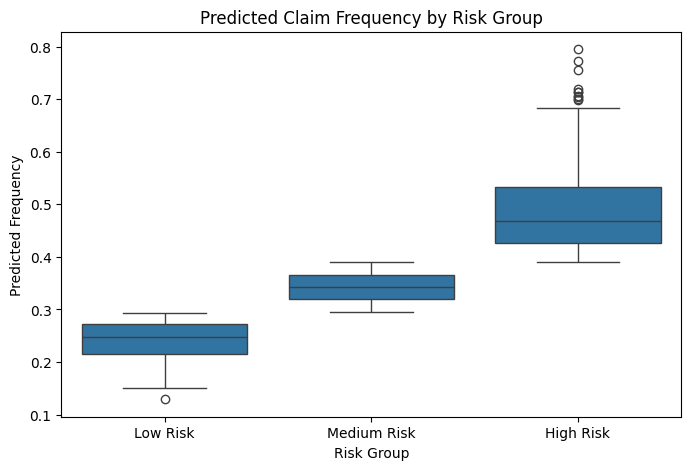

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=test,
    x="risk_group",
    y="predicted_frequency"
)

plt.title("Predicted Claim Frequency by Risk Group")

plt.xlabel("Risk Group")
plt.ylabel("Predicted Frequency")

plt.show()

**Feature Importance / Risk Factors**

In [56]:
print(nb_model.conf_int())
frequency_summary = pd.DataFrame({
    "Coefficient": nb_model.params,
    "Rate_Ratio": np.exp(nb_model.params),
    "P_Value": nb_model.pvalues,
    "CI_Lower": np.exp(
        nb_model.conf_int()[0]
    ),
    "CI_Upper": np.exp(
        nb_model.conf_int()[1]
    )
})

print(frequency_summary)

                       0         1
Intercept      -2.089114 -1.018308
age            -0.020390 -0.006719
vehicle_age     0.016331  0.073494
annual_mileage  0.000010  0.000051
policy_tenure   0.048455  0.197784
                Coefficient  Rate_Ratio       P_Value  CI_Lower  CI_Upper
Intercept         -1.553711    0.211462  1.287530e-08  0.123797  0.361206
age               -0.013554    0.986537  1.016795e-04  0.979817  0.993303
vehicle_age        0.044912    1.045936  2.071057e-03  1.016465  1.076262
annual_mileage     0.000030    1.000030  2.896689e-03  1.000010  1.000051
policy_tenure      0.123119    1.131019  1.229670e-03  1.049648  1.218699


### Claim Frequency Model

A Negative Binomial regression model was fitted to analyze the number of insurance claims. The model included age, vehicle age, annual mileage, and policy tenure as explanatory variables.

All four variables were statistically significant at the 5% significance level. Age had a negative coefficient (-0.013554) and a rate ratio of 0.986537, indicating that a one-year increase in age was associated with approximately a 1.35% decrease in expected claim frequency, holding other variables constant.

Vehicle age had a positive coefficient (0.044912) and a rate ratio of 1.045936. Thus, a one-year increase in vehicle age was associated with approximately a 4.59% increase in expected claim frequency.

Annual mileage had a positive coefficient of approximately 0.000030. Although the rate ratio per kilometre is very close to 1 because mileage is measured in kilometres, an increase of 1,000 km in annual mileage corresponds to approximately a 3.05% increase in expected claim frequency.

Policy tenure had a positive coefficient (0.123119) and a rate ratio of 1.131019. Therefore, a one-year increase in policy tenure was associated with approximately a 13.10% increase in expected claim frequency.

Overall, the results indicate that age is negatively associated with claim frequency, while vehicle age, annual mileage, and policy tenure are positively associated with claim frequency. All estimated associations were statistically significant at the 5% level.


Finding 1 — Claim Frequency

The claim frequency variable was modeled using count regression. Poisson regression was initially considered, while Negative Binomial regression was evaluated to account for potential overdispersion.

Finding 2 — Claim Severity

Claim severity was analyzed only among policyholders with positive claim amounts. Because claim amounts were positive and right-skewed, a Gamma regression with a log link was used.

Finding 3 — Risk Factors

The statistical analysis identified several policyholder and vehicle characteristics associated with claim frequency and/or severity. The direction and magnitude of these associations were evaluated using model coefficients and rate ratios.

Finding 4 — Risk Segmentation

Policyholders were divided into modeled risk groups based on predicted claim frequency. This segmentation provides a way to identify groups with different expected claim behavior.

Finding 5 — Expected Loss

Expected loss can be estimated by combining predicted claim frequency and predicted claim severity:

$$ \boxed{ E(Loss)=E(Frequency)\times E(Severity) } $$

**Conclusion:**
This project developed an insurance risk modeling framework based on claim frequency and claim severity. The analysis began with data cleaning and exploratory data analysis to understand the distribution of claims and identify potential risk factors. Claim frequency was modeled using Poisson and Negative Binomial regression, while positive claim severity was modeled using Gamma regression with a log link. Model coefficients, rate ratios, goodness-of-fit measures, and prediction errors were examined to understand the relationships between policyholder characteristics and insurance risk. Finally, predicted claim frequency was used to create risk segments. The analysis demonstrates how statistical modeling can support insurance risk assessment, expected-loss estimation, and data-driven pricing decisions.